In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("malaychand/coco-25-classification-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 185M/185M [00:02<00:00, 92.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/malaychand/coco-25-classification-dataset/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/malaychand/coco-25-classification-dataset/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/malaychand/coco-25-classification-dataset/versions/1):
['classification']


In [ ]:
print(f"Contents of the 'train' directory: {os.listdir(os.path.join(path, 'classification', 'train'))}")
print(f"Contents of the 'test' directory: {os.listdir(os.path.join(path, 'classification', 'test'))}")

Contents of the 'train' directory: ['car', 'stop sign', 'bird', 'pizza', 'bicycle', 'cup', 'train', 'dog', 'cake', 'bottle', 'cat', 'couch', 'airplane', 'bench', 'cow', 'bowl', 'horse', 'traffic light', 'truck', 'bus', 'elephant', 'person', 'chair', 'motorcycle', 'potted plant']
Contents of the 'test' directory: ['car', 'stop sign', 'bird', 'pizza', 'bicycle', 'cup', 'train', 'dog', 'cake', 'bottle', 'cat', 'couch', 'airplane', 'bench', 'cow', 'bowl', 'horse', 'traffic light', 'truck', 'bus', 'elephant', 'person', 'chair', 'motorcycle', 'potted plant']



--- Sample Images from Training Dataset (/root/.cache/kagglehub/datasets/malaychand/coco-25-classification-dataset/versions/1/classification/train) ---
Found 5250 images in /root/.cache/kagglehub/datasets/malaychand/coco-25-classification-dataset/versions/1/classification/train. Displaying 6 samples:


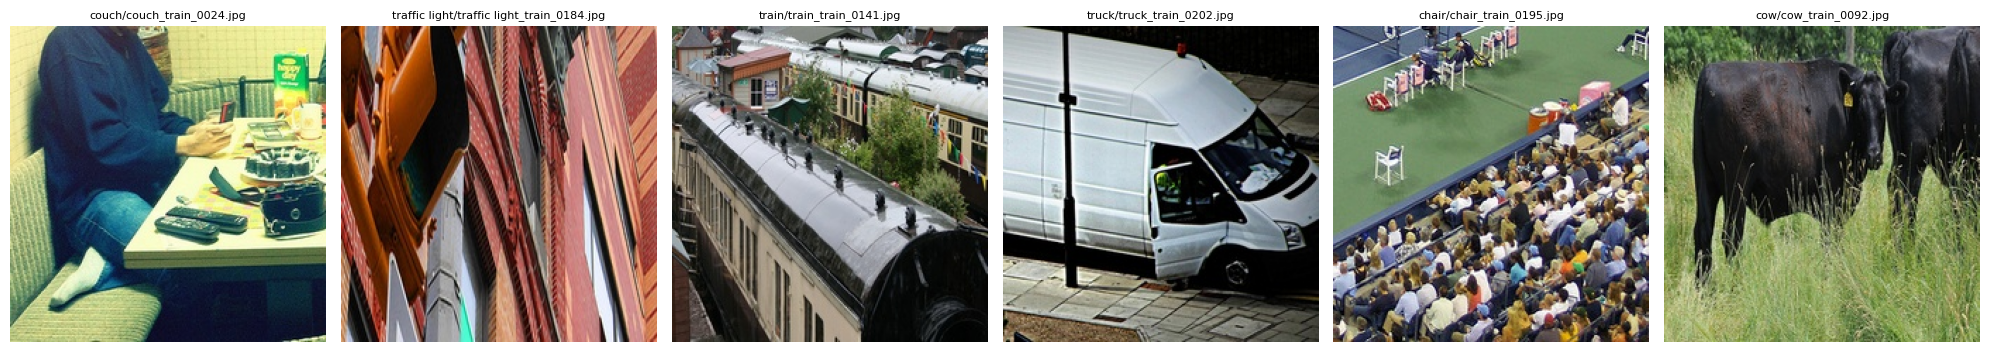


--- Sample Images from Test Dataset (/root/.cache/kagglehub/datasets/malaychand/coco-25-classification-dataset/versions/1/classification/test) ---
Found 750 images in /root/.cache/kagglehub/datasets/malaychand/coco-25-classification-dataset/versions/1/classification/test. Displaying 6 samples:


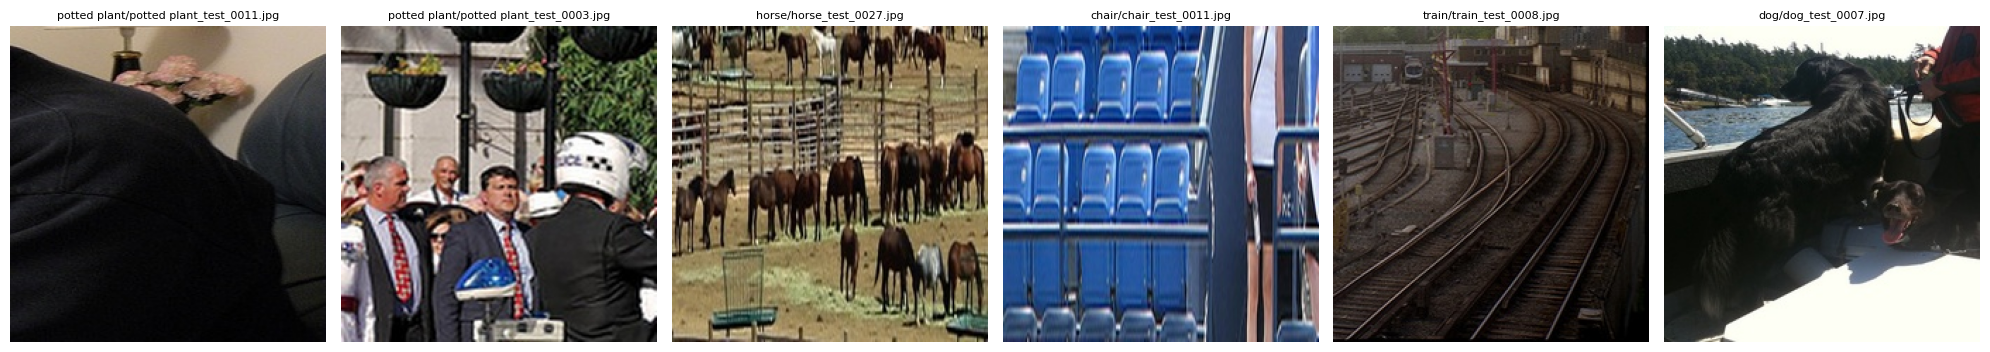

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images in {dataset_path}. Displaying {min(num_samples, len(all_image_paths))} samples:")

    # Select random samples to display
    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]
    elif len(samples_to_display) == 0:
        plt.close(fig)
        return

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(os.path.basename(os.path.dirname(img_path)) + '/' + os.path.basename(img_path), fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Updated paths to include 'classification' subdirectory
train_path = os.path.join(path, 'classification', 'train')
print(f"\n--- Sample Images from Training Dataset ({train_path}) ---")
display_sample_images(train_path)

test_path = os.path.join(path, 'classification', 'test')
print(f"\n--- Sample Images from Test Dataset ({test_path}) ---")
display_sample_images(test_path)

In [ ]:
import torch

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if device.type == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("Warning: GPU not found. Training will be slow on CPU.")

Using device: cuda
GPU Name: Tesla T4


In [ ]:
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader
import time

# Data preprocessing
transform = transforms.Compose([
    transforms.Resize((227, 227)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(root=train_path, transform=transform)
test_dataset = datasets.ImageFolder(root=test_path, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Defining AlexNet
model = models.alexnet(num_classes=25).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Training loop
num_epochs = 10
history = {'train_loss': [], 'train_acc': [], 'test_acc': []}

print("Starting Training...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100. * correct / total

    # Validation
    model.eval()
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            test_total += labels.size(0)
            test_correct += predicted.eq(labels).sum().item()

    test_acc = 100. * test_correct / test_total

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

print("Finished Training.")

Starting Training...
Epoch [1/10] Loss: 3.1771 | Train Acc: 6.06% | Test Acc: 7.20%
Epoch [2/10] Loss: 3.0086 | Train Acc: 11.54% | Test Acc: 12.00%
Epoch [3/10] Loss: 2.8226 | Train Acc: 15.87% | Test Acc: 17.87%
Epoch [4/10] Loss: 2.5401 | Train Acc: 25.54% | Test Acc: 26.13%
Epoch [5/10] Loss: 2.3082 | Train Acc: 33.89% | Test Acc: 33.60%
Epoch [6/10] Loss: 1.9593 | Train Acc: 43.89% | Test Acc: 38.93%
Epoch [7/10] Loss: 1.6750 | Train Acc: 51.47% | Test Acc: 48.93%
Epoch [8/10] Loss: 1.3459 | Train Acc: 61.58% | Test Acc: 53.07%
Epoch [9/10] Loss: 1.0804 | Train Acc: 68.13% | Test Acc: 59.20%
Epoch [10/10] Loss: 0.8492 | Train Acc: 74.63% | Test Acc: 62.93%
Finished Training.


In [ ]:
# Summary of training results
print("--- Training Summary ---")
print(f"Final Training Accuracy: {history['train_acc'][-1]:.2f}%")
print(f"Final Test Accuracy: {history['test_acc'][-1]:.2f}%")
print(f"Best Test Accuracy Reached: {max(history['test_acc']):.2f}%")

--- Training Summary ---
Final Training Accuracy: 74.63%
Final Test Accuracy: 62.93%
Best Test Accuracy Reached: 62.93%


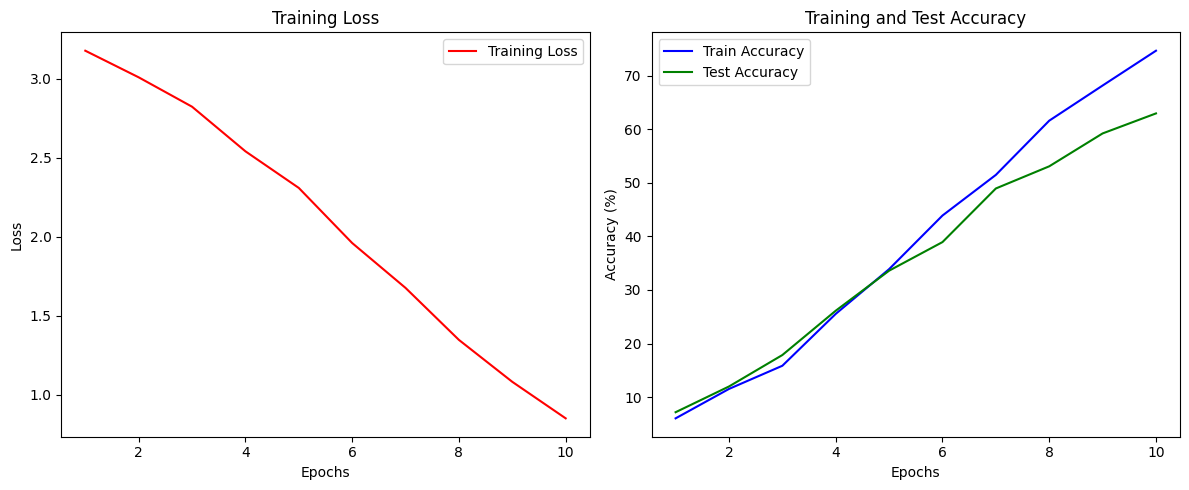

In [ ]:
import matplotlib.pyplot as plt

# Plotting training curves
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_loss'], 'r-', label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(epochs, history['train_acc'], 'b-', label='Train Accuracy')
plt.plot(epochs, history['test_acc'], 'g-', label='Test Accuracy')
plt.title('Training and Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()